# Vanilla RNN (SimpleRNN) — Sequence Modeling Types on Hourly Energy Data

This notebook builds **five classic RNN input/output typologies** — one-to-one,
many-to-one, one-to-many, many-to-many (synced), and many-to-many (encoder-decoder /
seq2seq) — all using **`tf.keras.layers.SimpleRNN`** as the recurrent
cell, via the Keras **Sequential API**. Every architecture is trained on the same
hourly Spanish electricity dataset (load, generation mix, price), so the only thing
that changes between sections is the *shape* of the supervised learning problem, not
the data or the cell type.

Each model trains for **100 epochs** and is drawn as a layer diagram before training
(`show_model_diagram`). Every `Sequential([...])` block also includes a **commented-out
second SimpleRNN layer** with a one-line note on what to flip — uncomment it
to go from a single-layer to a stacked (deep) recurrent network for that architecture.

## 1. The Vanilla RNN Cell


$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$
$$y_t = W_{hy} h_t + b_y$$

A single hidden state $h_t$ is recomputed at every timestep from the current input $x_t$
and the *previous* hidden state $h_{t-1}$, squashed through $\tanh$. There is no
separate "memory cell" and no gating — the same weight matrices $W_{xh}, W_{hh}$ are
reused (shared) at every timestep, which is what makes this a *recurrent* network
rather than one feedforward layer per timestep.

**Known weakness:** because $h_{t-1}$ is repeatedly multiplied by $W_{hh}$ and passed
through $\tanh$, gradients during backpropagation-through-time tend to either vanish
or explode over long sequences — this is the textbook motivation for LSTM and GRU,
which you'll build in the companion notebooks.


### What you'll build

1. Load & clean the hourly energy dataset (with an offline synthetic fallback)
2. Chronological train/val/test split + scaling
3. Windowing utilities shared by all five architectures
4. **One-to-one** — single step in, single step out
5. **Many-to-one** — a window of history, one prediction
6. **One-to-many** — one snapshot, a generated forecast sequence
7. **Many-to-many (synced)** — a window in, one aligned prediction per step
8. **Many-to-many (seq2seq)** — a window of history, a differently-sized future window
9. Side-by-side comparison of parameter counts and validation performance


## 1b. Setup and Imports

Model architecture diagrams later in this notebook (`show_model_diagram`) need the `pydot` package and the Graphviz `dot` executable. If they're missing, those cells print a note and skip the diagram — everything else still runs.
```bash
pip install pydot
# Debian/Ubuntu:
sudo apt-get install graphviz
# macOS:
brew install graphviz
```

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100


## 2. Dataset: Hourly Energy Demand, Generation, Price & Weather (Spain)

**Source:** [Hourly Energy Demand, Generation, Weather and Price — Kaggle](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)
(`nicholasjhana/energy-consumption-generation-prices-and-weather`)

The dataset contains ~4 years (2015–2018) of hourly Spanish electricity data in
`energy_dataset.csv`: total load, generation by source (solar, wind, gas, nuclear, ...),
day-ahead price forecasts, and actual settled prices.

**To use the real dataset**, do ONE of:

1. **Kaggle CLI** (needs a Kaggle account + API token at `~/.kaggle/kaggle.json`):
   ```bash
   pip install kaggle
   kaggle datasets download -d nicholasjhana/energy-consumption-generation-prices-and-weather -p data --unzip
   ```
2. **Manual download**: download `energy_dataset.csv` from the Kaggle page above and place it at `./data/energy_dataset.csv`.
3. **kagglehub** (cell below will try this automatically if installed and authenticated):
   ```bash
   pip install kagglehub
   ```

If none of the above is available, the loader below **falls back to a synthetic
dataset** with the same column names and realistic daily/weekly seasonality, so every
cell in this notebook still runs end-to-end without the real file. Swap in the real
CSV at any time — no other code needs to change, since every downstream cell only
depends on `FEATURE_COLS` / `TARGET_COL` existing in `df`.


In [5]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "data"
ENERGY_CSV = os.path.join(DATA_DIR, "/mnt/d/DIT/Bioinformatics/Code/Oct 4/energy_dataset.csv")

FEATURE_COLS = [
    "total load actual",
    "generation solar",
    "generation wind onshore",
    "generation fossil gas",
    "price actual",
]
TARGET_COL = "price actual"


def _make_synthetic_energy_data(n_hours: int = 3000, seed: int = 42) -> pd.DataFrame:
    """Stand-in dataset with the same schema/units as energy_dataset.csv, built
    from daily + weekly seasonal components plus noise, so the notebook can run
    fully offline without Kaggle credentials."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2018-01-01", periods=n_hours, freq="h", name="time")
    hour = idx.hour.values.astype(float)
    dow = idx.dayofweek.values.astype(float)
    day_frac = np.arange(n_hours) / 24.0

    daily = np.sin(2 * np.pi * hour / 24.0)
    weekly = np.sin(2 * np.pi * dow / 7.0)
    trend = 0.05 * np.sin(2 * np.pi * day_frac / 90.0)

    load = 26000 + 4000 * daily + 1200 * weekly + 1500 * trend + rng.normal(0, 400, n_hours)
    solar = np.clip(3500 * np.maximum(0, np.sin(2 * np.pi * (hour - 6) / 24.0)) + rng.normal(0, 150, n_hours), 0, None)
    wind = np.clip(4500 + 1800 * np.sin(2 * np.pi * day_frac / 5.0) + rng.normal(0, 600, n_hours), 0, None)
    gas = np.clip(6000 - 0.3 * (solar + wind) + rng.normal(0, 300, n_hours), 500, None)
    price = np.clip(
        55 + 8 * daily + 3 * weekly - 0.002 * (solar + wind) + rng.normal(0, 3.5, n_hours),
        5, None,
    )

    df = pd.DataFrame(
        {
            "total load actual": load,
            "generation solar": solar,
            "generation wind onshore": wind,
            "generation fossil gas": gas,
            "price actual": price,
        },
        index=idx,
    )
    return df


def load_energy_data() -> pd.DataFrame:
    if os.path.exists(ENERGY_CSV):
        print(f"Loading real dataset from {ENERGY_CSV}")
        df = pd.read_csv(ENERGY_CSV, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df

    try:
        import kagglehub

        path = kagglehub.dataset_download(
            "nicholasjhana/energy-consumption-generation-prices-and-weather"
        )
        csv_path = os.path.join(path, "energy_dataset.csv")
        print(f"Downloaded via kagglehub to {csv_path}")
        df = pd.read_csv(csv_path, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df
    except Exception as e:
        print(f"[info] Could not load the real Kaggle dataset ({type(e).__name__}: {e}).")
        print("[info] Falling back to a synthetic energy-like dataset (see DATA_LOADER_CODE) "
              "so the rest of the notebook still runs end-to-end.")
        print("[info] See section 2 above for instructions on installing the real dataset.")
        return _make_synthetic_energy_data()


df = load_energy_data()
print(df.shape)
df.head()

Loading real dataset from /mnt/d/DIT/Bioinformatics/Code/Oct 4/energy_dataset.csv
(35064, 28)


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
2015-01-01 02:00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
2015-01-01 03:00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [6]:
# Keep only the columns this notebook uses, make the index a clean hourly
# DatetimeIndex, and fill any gaps (the real Kaggle file has a handful of
# missing hours/values).
df = df[FEATURE_COLS].copy()
df = df[~df.index.duplicated(keep="first")]
df = df.asfreq("h")
df = df.interpolate(method="time").bfill().ffill()

print(f"Rows: {len(df)}   Range: {df.index.min()} -> {df.index.max()}")
df.describe().T

Rows: 35064   Range: 2014-12-31 23:00:00 -> 2018-12-31 22:00:00


,count,mean,std,min,25%,50%,75%,max
total load actual,35064.0,28698.281385,4575.828854,18041.00,24807.0000,28902.00,32194.25,41015.0
generation solar,35064.0,1432.818546,1679.961733,0.00,71.0000,616.00,2579.00,5792.0
generation wind onshore,35064.0,5464.980450,3213.586296,0.00,2933.0000,4849.50,7399.50,17436.0
generation fossil gas,35064.0,5622.700647,2201.510984,0.00,4126.0000,4969.50,6429.00,20034.0
price actual,35064.0,57.884023,14.204083,9.33,49.3475,58.02,68.01,116.8



## 3. Feature Engineering & Scaling

This is time-series data, so the train/validation/test split must be **chronological**
(no shuffling) — otherwise the model would be validated on data that "leaks" future
information it was trained on. We fit the scaler on the training slice only, then
apply it to validation/test, which mirrors how you'd deploy this in production
(you never get to peek at the future to normalize the past).


In [7]:
from sklearn.preprocessing import MinMaxScaler

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

scaler = MinMaxScaler()
scaler.fit(train_df.values)

train_scaled = pd.DataFrame(scaler.transform(train_df.values), columns=FEATURE_COLS, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df.values), columns=FEATURE_COLS, index=val_df.index)
test_scaled = pd.DataFrame(scaler.transform(test_df.values), columns=FEATURE_COLS, index=test_df.index)

TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
N_FEATURES = len(FEATURE_COLS)

print(f"train={len(train_scaled)}  val={len(val_scaled)}  test={len(test_scaled)}  n_features={N_FEATURES}")

train=24544  val=5260  test=5260  n_features=5



## 4. Windowing Utilities

Each RNN *type* below needs its (X, y) pairs built differently from the same
underlying hourly series. These five helpers turn a scaled dataframe into the
right tensor shapes for Keras:

| Type | X shape | y shape | Meaning |
|---|---|---|---|
| One-to-one | `(n, 1, features)` | `(n, 1)` | single timestep in -> single value out |
| Many-to-one | `(n, window, features)` | `(n, 1)` | a window of history -> next single value |
| One-to-many | `(n, 1, features)` | `(n, out_len, 1)` | a single timestep -> a forecast sequence |
| Many-to-many (synced) | `(n, window, features)` | `(n, window, 1)` | a window -> one prediction per input step |
| Many-to-many (seq2seq) | `(n, in_window, features)` | `(n, out_horizon, 1)` | a window of history -> a future window |

All five draw from `TARGET_COL` (`price actual`) as the value being predicted/generated.


In [8]:
def make_one_to_one(data: pd.DataFrame):
    """Single timestep in -> the very next single timestep's target out."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - 1):
        X.append(values[t : t + 1])          # (1, features)
        y.append([target[t + 1]])             # (1,)
    return np.array(X), np.array(y)


def make_many_to_one(data: pd.DataFrame, window: int = 24):
    """`window` hours of history -> the next single target value."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window):
        X.append(values[t : t + window])
        y.append([target[t + window]])
    return np.array(X), np.array(y)


def make_one_to_many(data: pd.DataFrame, out_len: int = 6):
    """A single timestep -> the next `out_len` hours of the target (a forecast run)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - out_len - 1):
        X.append(values[t : t + 1])
        y.append(target[t + 1 : t + 1 + out_len])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, out_len, 1)
    return X, y


def make_synced_many_to_many(data: pd.DataFrame, window: int = 24):
    """A window of `window` hours -> one target prediction per input step
    (each output position predicts the target one step ahead of the aligned input)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window - 1):
        X.append(values[t : t + window])
        y.append(target[t + 1 : t + window + 1])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, window, 1)
    return X, y


def make_seq2seq(data: pd.DataFrame, in_window: int = 24, out_horizon: int = 6):
    """`in_window` hours of history -> the following `out_horizon` hours of the target
    (classic encoder-decoder forecasting setup, input and output lengths differ)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - in_window - out_horizon):
        X.append(values[t : t + in_window])
        y.append(target[t + in_window : t + in_window + out_horizon])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, out_horizon, 1)
    return X, y


WINDOW = 24        # hours of history for many-to-one / synced many-to-many
OUT_LEN = 6         # forecast horizon for one-to-many / seq2seq
UNITS = 32
EPOCHS = 100
BATCH_SIZE = 64

# Optional: uncomment to stop training early once val_loss stops improving,
# instead of always running the full 100 epochs. Left off by default so the
# EPOCHS=100 setting above is honored exactly as configured.
# EARLY_STOPPING = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]
EARLY_STOPPING = None

print("Windowing utilities and hyperparameters ready.")

Windowing utilities and hyperparameters ready.


A small shared helper trains a compiled model and plots its loss curve + a sample prediction, so every architecture section below stays short and comparable.

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

history_log = {}   # architecture name -> keras History, used in the final comparison

# MinMaxScaler stores per-column min/max in the order of FEATURE_COLS — pull out
# the target column's so predictions can be plotted back in real units (EUR/MWh)
# instead of the raw [0, 1] scaled range the network trains on.
_TARGET_MIN = scaler.data_min_[TARGET_IDX]
_TARGET_MAX = scaler.data_max_[TARGET_IDX]


def inverse_target(scaled_values: np.ndarray) -> np.ndarray:
    """Undo MinMax scaling for TARGET_COL only, for human-readable plots."""
    return np.asarray(scaled_values) * (_TARGET_MAX - _TARGET_MIN) + _TARGET_MIN


def compile_and_fit(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=EARLY_STOPPING,
        verbose=0,
    )
    history_log[name] = history
    val_mae = history.history["val_mae"][-1]
    n_epochs_ran = len(history.history["loss"])
    print(f"{name}: ran {n_epochs_ran}/{epochs} epochs  "
          f"final val_loss={history.history['val_loss'][-1]:.5f}  val_mae={val_mae:.5f}  "
          f"params={model.count_params():,}")
    return history


def plot_history(history, title: str):
    """Loss + MAE curves side by side, on a log-scaled x-axis friendly to 100-epoch runs."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss (MSE, scaled)")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="train")
    axes[1].plot(history.history["val_mae"], label="val")
    axes[1].set_title(f"{title} — MAE (scaled)")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_point_prediction(y_true_scaled, y_pred_scaled, title: str, n_points: int = 200):
    """For single-value (many-to-one / one-to-one) outputs: true vs. predicted
    price in real EUR/MWh units, plus a scatter of predicted vs. actual."""
    y_true = inverse_target(y_true_scaled[:n_points]).squeeze()
    y_pred = inverse_target(y_pred_scaled[:n_points]).squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(y_true, label="true price")
    axes[0].plot(y_pred, label="predicted price")
    axes[0].set_title(f"{title} — forecast vs. actual")
    axes[0].set_xlabel("hour (validation set)")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()

    axes[1].scatter(y_true, y_pred, s=10, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
    axes[1].set_title(f"{title} — predicted vs. actual")
    axes[1].set_xlabel("actual price (EUR/MWh)")
    axes[1].set_ylabel("predicted price (EUR/MWh)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_sequence_prediction(y_true_scaled, y_pred_scaled, title: str, n_show: int = 4):
    """For sequence outputs: overlay a few example true vs. predicted sequences,
    converted back to real EUR/MWh units."""
    y_true = inverse_target(y_true_scaled)
    y_pred = inverse_target(y_pred_scaled)

    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3), sharey=True)
    idxs = np.linspace(0, len(y_true) - 1, n_show).astype(int)
    for ax, i in zip(axes, idxs):
        ax.plot(y_true[i].squeeze(), "o-", label="true", markersize=3)
        ax.plot(y_pred[i].squeeze(), "x--", label="pred", markersize=4)
        ax.set_title(f"sample {i}")
        ax.set_xlabel("step")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_model_diagram(model: tf.keras.Model, filename: str):
    """Render the layer graph (shapes + param flow) inline in the notebook."""
    try:
        return tf.keras.utils.plot_model(
            model, to_file=filename, show_shapes=True, show_layer_names=True, dpi=65
        )
    except Exception as e:
        print(f"[info] Could not render model diagram ({type(e).__name__}: {e}). "
              "This needs the 'pydot' package and the Graphviz 'dot' executable installed.")
        return None


def draw_rnn_typology(pattern, title, cell_label="RNN", encoder_decoder=False, split=None,
                       context_label="context vector", figsize=(9, 3)):
    """Classic 'unrolled cells in a row' illustration of an RNN input/output
    typology (the diagram style used throughout the RNN/LSTM/GRU literature),
    independent of any particular Keras layer plumbing.

    pattern: list of (has_input, has_output) booleans, one per unrolled timestep.
    encoder_decoder: color cells before `split` as an encoder and from `split`
        onward as a decoder, with a labeled hand-off arrow at the seam
        (illustrates the RepeatVector/context-vector pattern used by the
        seq2seq and one-to-many architectures below).
    """
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyBboxPatch

    n = len(pattern)
    fig, ax = plt.subplots(figsize=figsize)
    box_w, box_h = 0.95, 0.6
    xs = [i * 1.7 for i in range(n)]
    y_cell = 0

    encoder_color, decoder_color, plain_color = "#4C72B0", "#DD8452", "#55A868"

    for i, (has_in, has_out) in enumerate(pattern):
        x = xs[i]
        if encoder_decoder and split is not None:
            color = encoder_color if i < split else decoder_color
            role = "enc" if i < split else "dec"
            label = f"{cell_label}\n({role})"
        else:
            color = plain_color
            label = cell_label

        box = FancyBboxPatch(
            (x - box_w / 2, y_cell - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05,rounding_size=0.08",
            linewidth=1.3, edgecolor="black", facecolor=color, alpha=0.9,
        )
        ax.add_patch(box)
        ax.text(x, y_cell, label, ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        if i < n - 1:
            seam = encoder_decoder and split is not None and (i + 1 == split)
            ax.annotate(
                "", xy=(xs[i + 1] - box_w / 2, y_cell), xytext=(x + box_w / 2, y_cell),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.0 if seam else 1.3,
                                 linestyle="dashed" if seam else "solid"),
            )
            if seam:
                ax.text((x + xs[i + 1]) / 2, y_cell + 0.42, context_label,
                         ha="center", va="bottom", fontsize=7.5, style="italic")

        if has_in:
            ax.annotate("", xy=(x, y_cell - box_h / 2), xytext=(x, y_cell - box_h / 2 - 0.5),
                        arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.2))
            ax.text(x, y_cell - box_h / 2 - 0.62, "$x_t$", ha="center", va="top", fontsize=9)
        if has_out:
            ax.annotate("", xy=(x, y_cell + box_h / 2 + 0.5), xytext=(x, y_cell + box_h / 2),
                        arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.2))
            ax.text(x, y_cell + box_h / 2 + 0.62, "$y_t$", ha="center", va="bottom", fontsize=9)

    ax.set_xlim(xs[0] - 1.2, xs[-1] + 1.2)
    ax.set_ylim(-1.55, 1.55)
    ax.axis("off")
    ax.set_title(title, fontsize=11)

    if encoder_decoder and split is not None:
        handles = [
            mpatches.Patch(color=encoder_color, label="encoder"),
            mpatches.Patch(color=decoder_color, label="decoder"),
        ]
        ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()

I0000 00:00:1791077314.142968     419 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791077318.309150     419 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791077364.709349     419 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 5. Architecture Type A — One-to-One

The degenerate case: a single input timestep predicts a single output value one
step ahead. With only one timestep there's nothing to "recur" over yet — this is
included mainly to anchor the typology; a Vanilla RNN layer with a sequence
length of 1 behaves like a Dense layer applied to that timestep, which is exactly
what you'll see reflected in its parameter count in the final comparison.

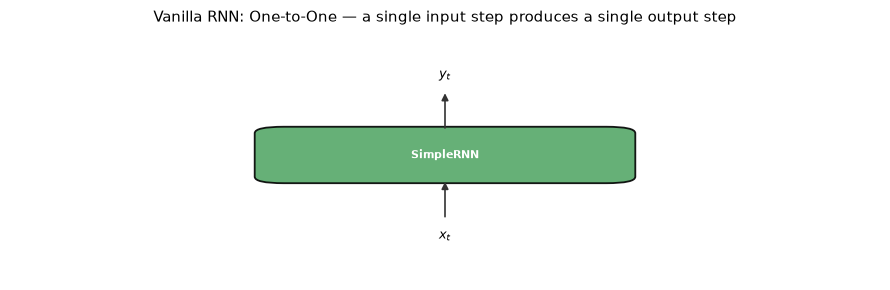

In [10]:
draw_rnn_typology(
    pattern=[(True, True)],
    title="Vanilla RNN: One-to-One — a single input step produces a single output step",
    cell_label="SimpleRNN",
)

In [11]:
X1, y1 = make_one_to_one(train_scaled)
Xv1, yv1 = make_one_to_one(val_scaled)
print("X shape:", X1.shape, " y shape:", y1.shape)

model_one_to_one = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),
    tf.keras.layers.Dense(1),
], name="vanilla_rnn_one_to_one")

model_one_to_one.summary()
show_model_diagram(model_one_to_one, "vanilla_rnn_one_to_one.png")

X shape: (24543, 1, 5)  y shape: (24543, 1)


E0000 00:00:1791077389.705088     419 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "vanilla_rnn_one_to_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1, 32)          │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


one_to_one: ran 100/100 epochs  final val_loss=0.00161  val_mae=0.02781  params=3,329


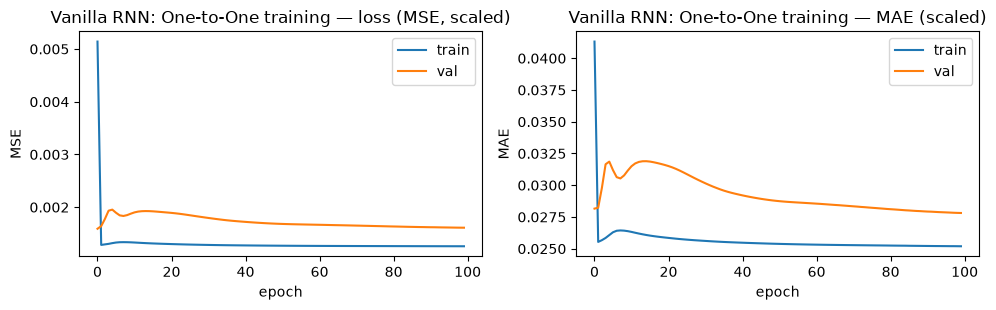

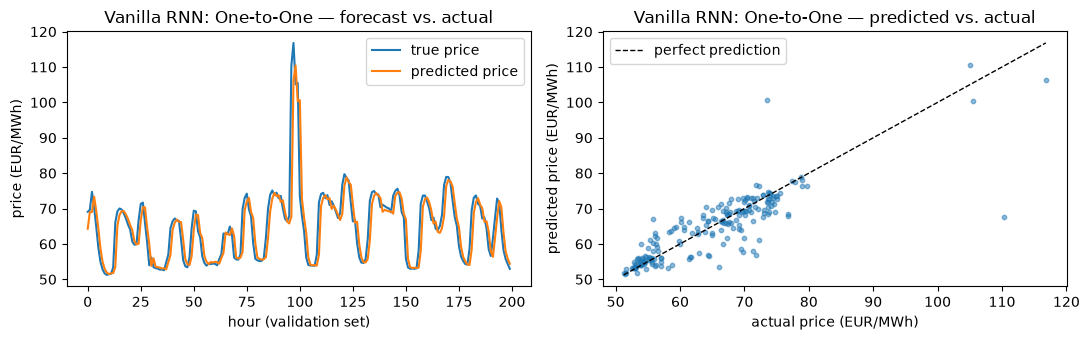

In [12]:
hist_1to1 = compile_and_fit(model_one_to_one, "one_to_one", X1, y1, Xv1, yv1)
plot_history(hist_1to1, "Vanilla RNN: One-to-One training")

pred = model_one_to_one.predict(Xv1, verbose=0)
plot_point_prediction(yv1, pred, "Vanilla RNN: One-to-One")

## 6. Architecture Type B — Many-to-One

`return_sequences=False` (the Keras default): the Vanilla RNN layer consumes
the full `WINDOW`-hour window and only its **final** hidden state is passed to the
Dense output layer. This is the classic setup for "predict the next value from
recent history" — e.g. tomorrow's price from the last 24 hours of load/generation/price.

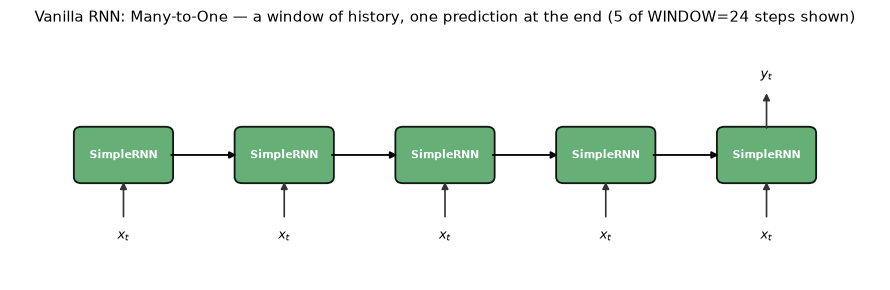

In [13]:
draw_rnn_typology(
    pattern=[(True, False)] * 4 + [(True, True)],
    title=f"Vanilla RNN: Many-to-One — a window of history, one prediction at the end (5 of WINDOW={WINDOW} steps shown)",
    cell_label="SimpleRNN",
)

In [14]:
Xm1, ym1 = make_many_to_one(train_scaled, window=WINDOW)
Xv_m1, yv_m1 = make_many_to_one(val_scaled, window=WINDOW)
print("X shape:", Xm1.shape, " y shape:", ym1.shape)

model_many_to_one = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),
    tf.keras.layers.Dense(1),
], name="vanilla_rnn_many_to_one")

model_many_to_one.summary()
show_model_diagram(model_many_to_one, "vanilla_rnn_many_to_one.png")

X shape: (24520, 24, 5)  y shape: (24520, 1)


Model: "vanilla_rnn_many_to_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 24, 32)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_one: ran 100/100 epochs  final val_loss=0.00082  val_mae=0.02055  params=3,329


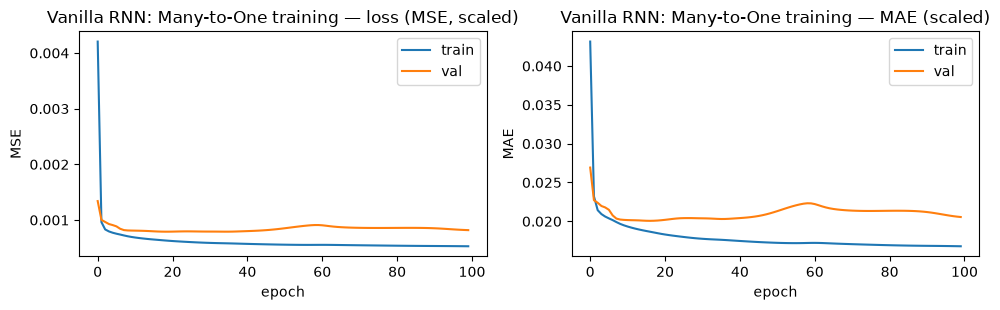

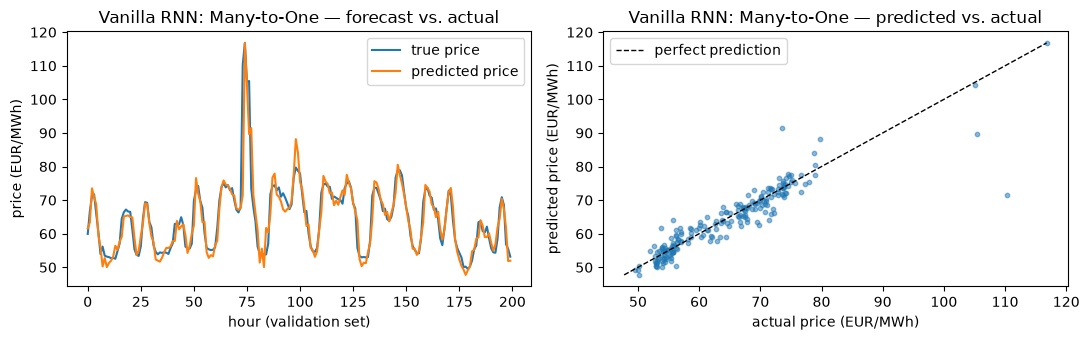

In [15]:
hist_m21 = compile_and_fit(model_many_to_one, "many_to_one", Xm1, ym1, Xv_m1, yv_m1)
plot_history(hist_m21, "Vanilla RNN: Many-to-One training")

pred = model_many_to_one.predict(Xv_m1, verbose=0)
plot_point_prediction(yv_m1, pred, "Vanilla RNN: Many-to-One")

## 7. Architecture Type C — One-to-Many

A single timestep is encoded into a hidden state, `RepeatVector(OUT_LEN)` copies that
state to seed every step of a *second* Vanilla RNN layer (`return_sequences=True`),
and `TimeDistributed(Dense(1))` applies the same output projection independently at
every generated step. This turns one snapshot into a generated sequence — e.g. one
hour's conditions kicking off a `{OUT_LEN}`-hour price forecast run, or (more classically)
one image feature vector generating a caption word-by-word.

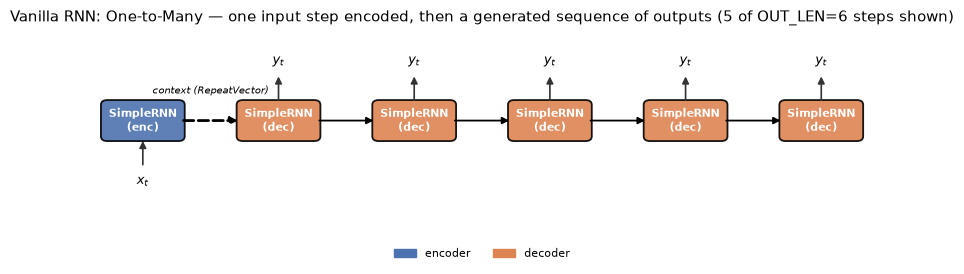

In [16]:
draw_rnn_typology(
    pattern=[(True, False)] + [(False, True)] * 5,
    title=f"Vanilla RNN: One-to-Many — one input step encoded, then a generated sequence of outputs (5 of OUT_LEN={OUT_LEN} steps shown)",
    cell_label="SimpleRNN",
    encoder_decoder=True,
    split=1,
    context_label="context (RepeatVector)",
)

In [17]:
Xo, yo = make_one_to_many(train_scaled, out_len=OUT_LEN)
Xv_o, yv_o = make_one_to_many(val_scaled, out_len=OUT_LEN)
print("X shape:", Xo.shape, " y shape:", yo.shape)

model_one_to_many = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),   # encoder
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),  # 2nd encoder layer
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),    # decoder
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),   # 2nd decoder layer
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="vanilla_rnn_one_to_many")

model_one_to_many.summary()
show_model_diagram(model_one_to_many, "vanilla_rnn_one_to_many.png")

X shape: (24537, 1, 5)  y shape: (24537, 6, 1)


Model: "vanilla_rnn_one_to_many"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 1, 32)          │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 6, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 6, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,489 (29.25 KB)

 Trainable params: 7,489 (29.25 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


one_to_many: ran 100/100 epochs  final val_loss=0.00719  val_mae=0.06305  params=7,489


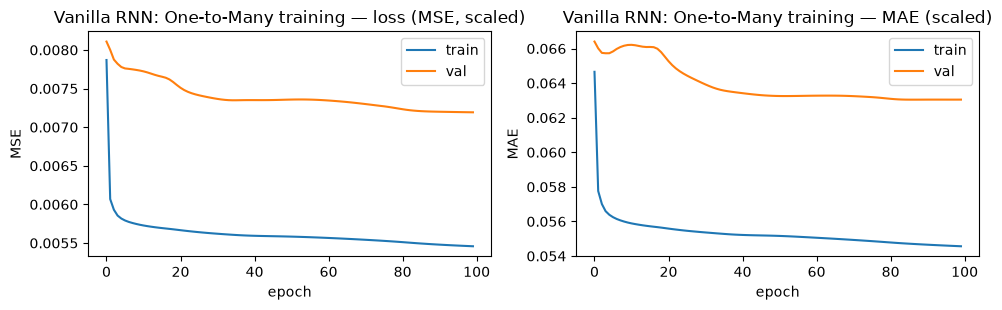

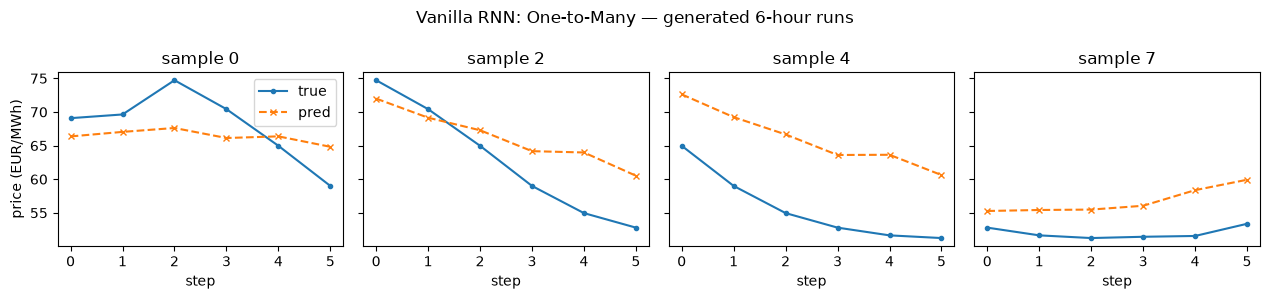

In [18]:
hist_1tm = compile_and_fit(model_one_to_many, "one_to_many", Xo, yo, Xv_o, yv_o)
plot_history(hist_1tm, "Vanilla RNN: One-to-Many training")

pred = model_one_to_many.predict(Xv_o[:8], verbose=0)
plot_sequence_prediction(yv_o[:8], pred, f"Vanilla RNN: One-to-Many — generated {OUT_LEN}-hour runs")

## 8. Architecture Type D — Many-to-Many (Synced)

`return_sequences=True` on a *single* Vanilla RNN layer, wrapped by
`TimeDistributed(Dense(1))`: the network emits one prediction **per input timestep**,
aligned in lockstep with the input (output length == input length). This is the shape
used for per-timestep sequence labeling tasks (POS tagging, per-frame classification)
— here, predicting the next hour's price at every position of a sliding window,
rather than only at the end as Many-to-One does.

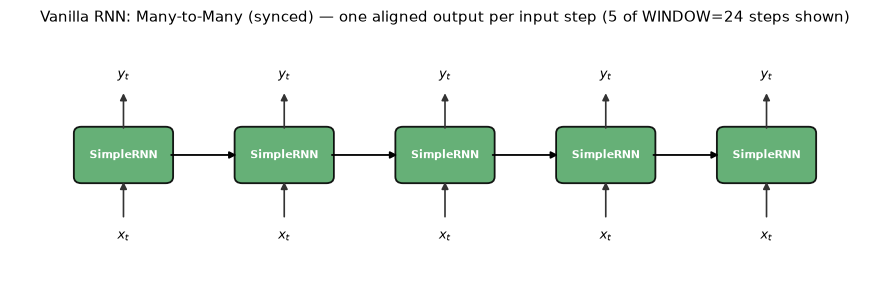

In [19]:
draw_rnn_typology(
    pattern=[(True, True)] * 5,
    title=f"Vanilla RNN: Many-to-Many (synced) — one aligned output per input step (5 of WINDOW={WINDOW} steps shown)",
    cell_label="SimpleRNN",
)

In [20]:
Xs, ys = make_synced_many_to_many(train_scaled, window=WINDOW)
Xv_s, yv_s = make_synced_many_to_many(val_scaled, window=WINDOW)
print("X shape:", Xs.shape, " y shape:", ys.shape)

model_synced = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="vanilla_rnn_synced_many_to_many")

model_synced.summary()
show_model_diagram(model_synced, "vanilla_rnn_synced_many_to_many.png")

X shape: (24519, 24, 5)  y shape: (24519, 24, 1)


Model: "vanilla_rnn_synced_many_to_many"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_8 (SimpleRNN)        │ (None, 24, 32)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 24, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_many_synced: ran 100/100 epochs  final val_loss=0.00091  val_mae=0.02146  params=3,329


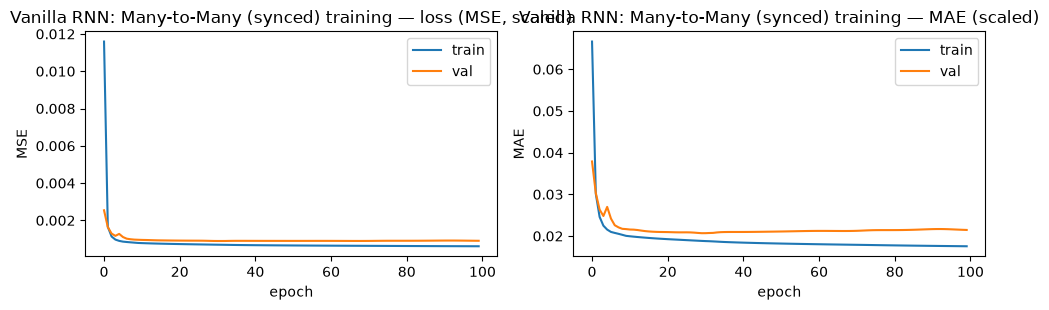

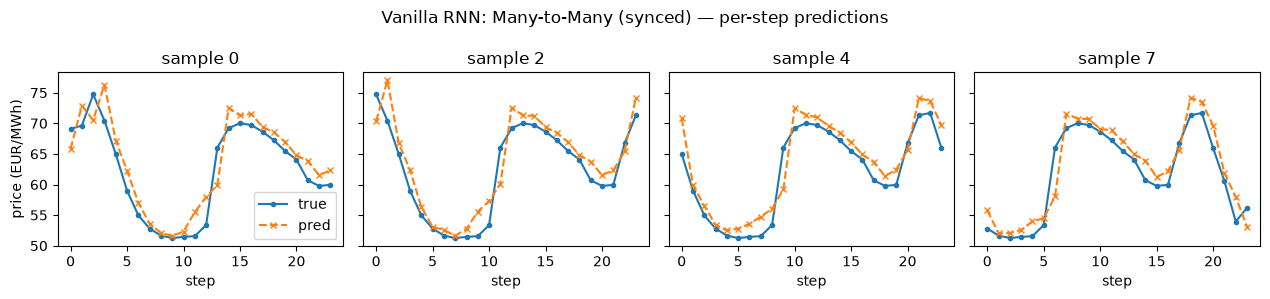

In [21]:
hist_sync = compile_and_fit(model_synced, "many_to_many_synced", Xs, ys, Xv_s, yv_s)
plot_history(hist_sync, "Vanilla RNN: Many-to-Many (synced) training")

pred = model_synced.predict(Xv_s[:8], verbose=0)
plot_sequence_prediction(yv_s[:8], pred, "Vanilla RNN: Many-to-Many (synced) — per-step predictions")

## 9. Architecture Type E — Many-to-Many (Encoder–Decoder / Seq2Seq)

The general many-to-many case, where input length and output length can differ
(`IN_WINDOW={WINDOW}` hours in, `OUT_HORIZON={OUT_LEN}` hours out). An **encoder**
Vanilla RNN compresses the input window into a single context vector
(`return_sequences=False`); `RepeatVector` seeds a **decoder** Vanilla RNN
(`return_sequences=True`); `TimeDistributed(Dense(1))` projects each decoder step to
a prediction. This is the same encoder-decoder pattern used for machine translation
and multi-step time-series forecasting — the "sequence in, differently-sized
sequence out" case that Many-to-One and the synced Many-to-Many above can't express.

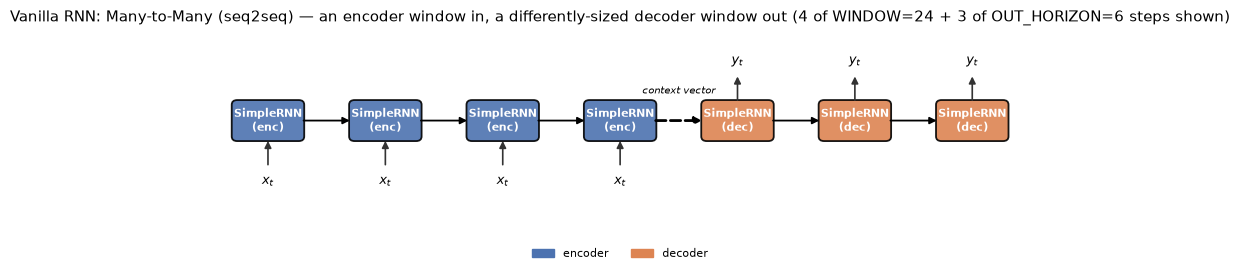

In [22]:
draw_rnn_typology(
    pattern=[(True, False)] * 4 + [(False, True)] * 3,
    title=f"Vanilla RNN: Many-to-Many (seq2seq) — an encoder window in, a differently-sized decoder window out (4 of WINDOW={WINDOW} + 3 of OUT_HORIZON={OUT_LEN} steps shown)",
    cell_label="SimpleRNN",
    encoder_decoder=True,
    split=4,
    context_label="context vector",
)

In [23]:
Xe, ye = make_seq2seq(train_scaled, in_window=WINDOW, out_horizon=OUT_LEN)
Xv_e, yv_e = make_seq2seq(val_scaled, in_window=WINDOW, out_horizon=OUT_LEN)
print("X shape:", Xe.shape, " y shape:", ye.shape)

model_seq2seq = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),   # encoder
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),  # 2nd encoder layer
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),    # decoder
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),   # 2nd decoder layer
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="vanilla_rnn_seq2seq")

model_seq2seq.summary()
show_model_diagram(model_seq2seq, "vanilla_rnn_seq2seq.png")

X shape: (24514, 24, 5)  y shape: (24514, 6, 1)


Model: "vanilla_rnn_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_10 (SimpleRNN)       │ (None, 24, 32)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ (None, 6, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 6, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,489 (29.25 KB)

 Trainable params: 7,489 (29.25 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_many_seq2seq: ran 100/100 epochs  final val_loss=0.00278  val_mae=0.03816  params=7,489


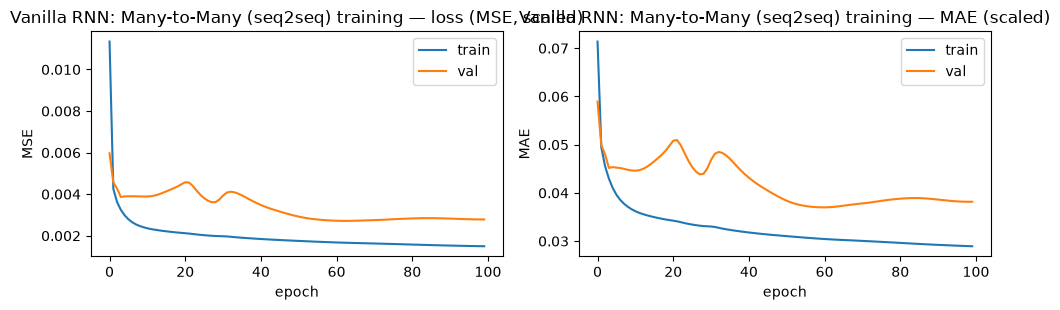

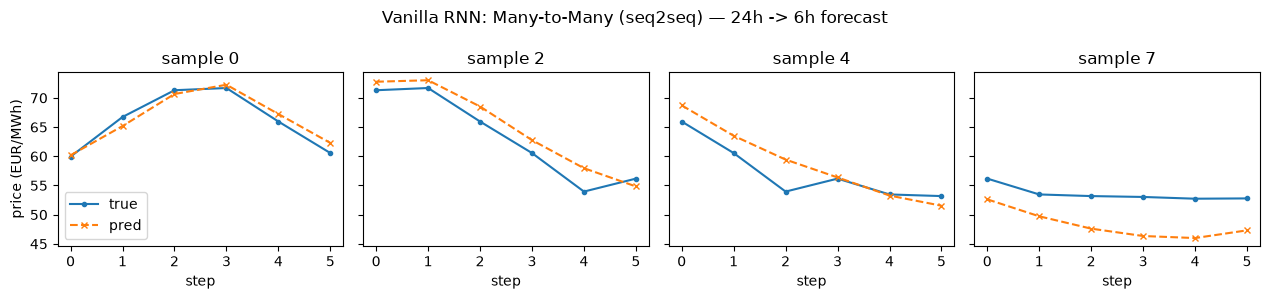

In [24]:
hist_s2s = compile_and_fit(model_seq2seq, "many_to_many_seq2seq", Xe, ye, Xv_e, yv_e)
plot_history(hist_s2s, "Vanilla RNN: Many-to-Many (seq2seq) training")

pred = model_seq2seq.predict(Xv_e[:8], verbose=0)
plot_sequence_prediction(yv_e[:8], pred, f"Vanilla RNN: Many-to-Many (seq2seq) — {WINDOW}h -> {OUT_LEN}h forecast")

## 10. Summary & Comparison

Recap of the five typologies built above, all using the same **Vanilla RNN** cell:

| Type | Input shape | Output shape | `return_sequences` pattern | Example use here |
|---|---|---|---|---|
| One-to-one | `(1, features)` | `(1,)` | n/a (single step) | next-hour price from this hour only |
| Many-to-one | `(window, features)` | `(1,)` | `False` | next-hour price from last 24h |
| One-to-many | `(1, features)` | `(out_len, 1)` | encoder `False`, decoder `True` | generate a {OUT_LEN}-hour forecast from one snapshot |
| Many-to-many (synced) | `(window, features)` | `(window, 1)` | `True` | per-step next-value prediction |
| Many-to-many (seq2seq) | `(in_window, features)` | `(out_horizon, 1)` | encoder `False`, decoder `True` | {WINDOW}h history -> {OUT_LEN}h forecast |

The cell below tabulates trained parameter counts and final validation loss/MAE for
every architecture in this notebook, so you can see how model size scales with the
task shape even though the underlying Vanilla RNN cell is identical throughout.

In [25]:
rows = []
for name, model in [
    ("one_to_one", model_one_to_one),
    ("many_to_one", model_many_to_one),
    ("one_to_many", model_one_to_many),
    ("many_to_many_synced", model_synced),
    ("many_to_many_seq2seq", model_seq2seq),
]:
    h = history_log[name]
    rows.append({
        "architecture": name,
        "params": model.count_params(),
        "final_val_loss_mse": h.history["val_loss"][-1],
        "final_val_mae": h.history["val_mae"][-1],
    })

summary_df = pd.DataFrame(rows).set_index("architecture")
summary_df

,params,final_val_loss_mse,final_val_mae
architecture,,,
one_to_one,3329,0.001611,0.027814
many_to_one,3329,0.000819,0.020552
one_to_many,7489,0.007193,0.063047
many_to_many_synced,3329,0.000906,0.021456
many_to_many_seq2seq,7489,0.002784,0.038164


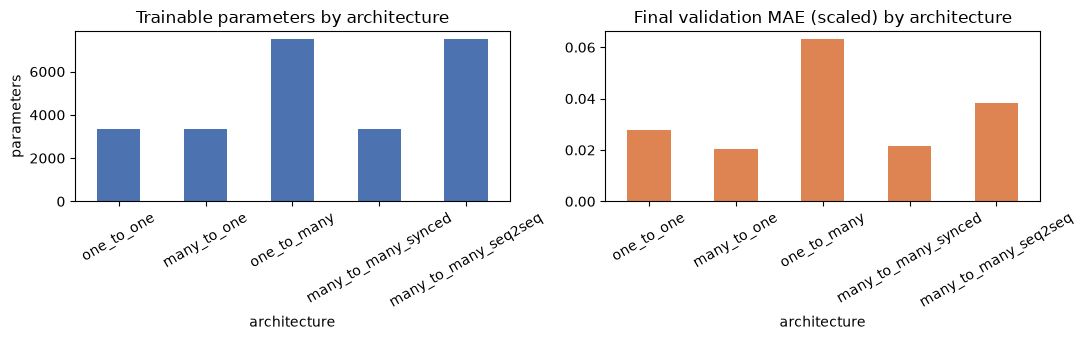

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
summary_df["params"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Trainable parameters by architecture")
axes[0].set_ylabel("parameters")
axes[0].tick_params(axis="x", rotation=30)

summary_df["final_val_mae"].plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("Final validation MAE (scaled) by architecture")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## References & Notes

- Dataset: Nicholas J. Hana, *Hourly Energy Demand Generation and Weather*, Kaggle
  (`nicholasjhana/energy-consumption-generation-prices-and-weather`).
- Hochreiter & Schmidhuber (1997), *Long Short-Term Memory*, Neural Computation 9(8).
- Cho et al. (2014), *Learning Phrase Representations using RNN Encoder-Decoder for
  Statistical Machine Translation* (introduces the GRU).
- Karpathy, *The Unreasonable Effectiveness of Recurrent Neural Networks* — the
  original source of the one-to-one / one-to-many / many-to-one / many-to-many
  diagram this notebook implements in code.

**Watch how quickly validation loss plateaus (or gets noisy) compared to the LSTM/GRU notebooks on the same windows — that gap is the vanishing-gradient effect in practice, not just in theory.**

**Companion notebooks:** the other two files in this set repeat every architecture
above with the same data pipeline, swapping only the recurrent cell
(`SimpleRNN` / `LSTM` / `GRU`) — use them side by side to compare parameter counts,
training curves, and forecast quality across cell types on identical tasks.

In [27]:
# ## 11. Test Metrics for the Stacked SimpleRNN Models

# The earlier five SimpleRNN definitions now contain an additional recurrent layer with the same 32 units. Metrics below are 
# calculated on the untouched chronological **test set**, after converting predictions back to EUR/MWh. Lower MAE, MSE, and RMSE are better; higher R² is better, with 1.0 representing a perfect fit.

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true_scaled, y_pred_scaled):
    """Return test metrics in the target's original EUR/MWh scale."""
    y_true = inverse_target(np.asarray(y_true_scaled)).reshape(-1)
    y_pred = inverse_target(np.asarray(y_pred_scaled)).reshape(-1)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }

# Build test tensors with exactly the same rules used for training.
Xt1, yt1 = make_one_to_one(test_scaled)
Xt_m1, yt_m1 = make_many_to_one(test_scaled, window=WINDOW)
Xt_o, yt_o = make_one_to_many(test_scaled, out_len=OUT_LEN)
Xt_s, yt_s = make_synced_many_to_many(test_scaled, window=WINDOW)
Xt_e, yt_e = make_seq2seq(test_scaled, in_window=WINDOW, out_horizon=OUT_LEN)

datasets = {
    "one_to_one": (X1, y1, Xv1, yv1, Xt1, yt1),
    "many_to_one": (Xm1, ym1, Xv_m1, yv_m1, Xt_m1, yt_m1),
    "one_to_many": (Xo, yo, Xv_o, yv_o, Xt_o, yt_o),
    "many_to_many_synced": (Xs, ys, Xv_s, yv_s, Xt_s, yt_s),
    "many_to_many_seq2seq": (Xe, ye, Xv_e, yv_e, Xt_e, yt_e),
}

simple_rnn_models = {
    "one_to_one": model_one_to_one,
    "many_to_one": model_many_to_one,
    "one_to_many": model_one_to_many,
    "many_to_many_synced": model_synced,
    "many_to_many_seq2seq": model_seq2seq,
}

all_metric_rows = []
for typology, model in simple_rnn_models.items():
    X_test, y_test = datasets[typology][4:]
    pred = model.predict(X_test, verbose=0)
    all_metric_rows.append({"cell_type": "SimpleRNN", "typology": typology,
                            "parameters": model.count_params(),
                            **regression_metrics(y_test, pred)})

pd.DataFrame(all_metric_rows).round(4)


,cell_type,typology,parameters,MAE,MSE,RMSE,R2
0,SimpleRNN,one_to_one,3329,2.2534,9.3823,3.0631,0.8498
1,SimpleRNN,many_to_one,3329,1.5987,4.4090,2.0998,0.9296
2,SimpleRNN,one_to_many,7489,4.7007,41.3770,6.4325,0.3382
3,SimpleRNN,many_to_many_synced,3329,1.6048,4.7258,2.1739,0.9246
4,SimpleRNN,many_to_many_seq2seq,7489,3.8528,22.3514,4.7277,0.6435


In [29]:
# ## 12. Add the Same Extra Layer to LSTM and GRU

# The builder below repeats the five typologies with LSTM and GRU cells. For ordinary stacks, the first recurrent layer returns the complete sequence so that the second recurrent layer can receive 3-D input. In encoder–decoder typologies, both the encoder and decoder contain two recurrent layers with 32 units each.

In [30]:
def build_stacked_model(cell_name, typology, units=UNITS):
    """Build one stacked SimpleRNN/LSTM/GRU model for a selected typology."""
    layer_cls = {
        "SimpleRNN": tf.keras.layers.SimpleRNN,
        "LSTM": tf.keras.layers.LSTM,
        "GRU": tf.keras.layers.GRU,
    }[cell_name]

    if typology == "one_to_one":
        layers = [tf.keras.layers.Input((1, N_FEATURES)),
                  layer_cls(units, return_sequences=True),
                  layer_cls(units, return_sequences=False),
                  tf.keras.layers.Dense(1)]
    elif typology == "many_to_one":
        layers = [tf.keras.layers.Input((WINDOW, N_FEATURES)),
                  layer_cls(units, return_sequences=True),
                  layer_cls(units, return_sequences=False),
                  tf.keras.layers.Dense(1)]
    elif typology == "one_to_many":
        layers = [tf.keras.layers.Input((1, N_FEATURES)),
                  layer_cls(units, return_sequences=True),
                  layer_cls(units, return_sequences=False),
                  tf.keras.layers.RepeatVector(OUT_LEN),
                  layer_cls(units, return_sequences=True),
                  layer_cls(units, return_sequences=True),
                  tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))]
    elif typology == "many_to_many_synced":
        layers = [tf.keras.layers.Input((WINDOW, N_FEATURES)),
                  layer_cls(units, return_sequences=True),
                  layer_cls(units, return_sequences=True),
                  tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))]
    elif typology == "many_to_many_seq2seq":
        layers = [tf.keras.layers.Input((WINDOW, N_FEATURES)),
                  layer_cls(units, return_sequences=True),
                  layer_cls(units, return_sequences=False),
                  tf.keras.layers.RepeatVector(OUT_LEN),
                  layer_cls(units, return_sequences=True),
                  layer_cls(units, return_sequences=True),
                  tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))]
    else:
        raise ValueError(f"Unknown typology: {typology}")
    return tf.keras.Sequential(layers, name=f"stacked_{cell_name.lower()}_{typology}")

print("Stacked model builder ready.")


Stacked model builder ready.


In [ ]:
# Train the ten added models: five LSTM typologies and five GRU typologies.
# This cell can take time because each model runs EPOCHS=100 by default.
trained_models = {}
for cell_name in ["LSTM", "GRU"]:
    for typology, (X_train, y_train, X_val, y_val, X_test, y_test) in datasets.items():
        print(f"\nTraining {cell_name} — {typology}")
        tf.keras.backend.clear_session()
        tf.random.set_seed(42)
        model = build_stacked_model(cell_name, typology)
        compile_and_fit(model, f"{cell_name}_{typology}",
                        X_train, y_train, X_val, y_val, epochs=EPOCHS)
        pred = model.predict(X_test, verbose=0)
        all_metric_rows.append({"cell_type": cell_name, "typology": typology,
                                "parameters": model.count_params(),
                                **regression_metrics(y_test, pred)})
        trained_models[(cell_name, typology)] = model

metrics_df = (pd.DataFrame(all_metric_rows)
              .sort_values(["typology", "RMSE"])
              .reset_index(drop=True))
metrics_df.round(4)



Training LSTM — one_to_one
LSTM_one_to_one: ran 100/100 epochs  final val_loss=0.00160  val_mae=0.02738  params=13,217

Training LSTM — many_to_one


In [ ]:
# 13. Which Cell Type Is Best After Adding Another Layer?
# Since each typology predicts a different output structure, models are ranked within each typology using test RMSE. R² is displayed as supporting information. This avoids treating unlike tasks as though their errors were directly interchangeable.

In [ ]:
best_by_typology = (
    metrics_df.loc[metrics_df.groupby("typology")["RMSE"].idxmin(),
                   ["typology", "cell_type", "MAE", "MSE", "RMSE", "R2", "parameters"]]
    .sort_values("typology")
    .reset_index(drop=True)
)
print("Best stacked recurrent cell for each typology (lowest test RMSE):")
display(best_by_typology.round(4))

print("\nOverall lowest RMSE (descriptive only; typologies have different tasks):")
display(metrics_df.nsmallest(1, "RMSE").round(4))


In [ ]:
# Visual comparison of test RMSE; shorter bars are better.
pivot_rmse = metrics_df.pivot(index="typology", columns="cell_type", values="RMSE")
ax = pivot_rmse.plot.bar(figsize=(11, 4.5))
ax.set_title("Stacked SimpleRNN vs LSTM vs GRU — test RMSE")
ax.set_ylabel("RMSE (EUR/MWh)")
ax.set_xlabel("Typology")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

cnn_rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, padding="same", activation="relu"),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),
    tf.keras.layers.Dense(1),
], name="cnn_stacked_rnn_many_to_one")

cnn_rnn_model.summary()
show_model_diagram(cnn_rnn_model, "cnn_stacked_rnn_many_to_one.png")

cnn_history = compile_and_fit(
    cnn_rnn_model, "CNN_SimpleRNN_many_to_one",
    Xm1, ym1, Xv_m1, yv_m1, epochs=100
)
plot_history(cnn_history, "CNN + stacked SimpleRNN: Many-to-One")

cnn_pred = cnn_rnn_model.predict(Xt_m1, verbose=0)
cnn_metrics = regression_metrics(yt_m1, cnn_pred)
pd.DataFrame([{"model": "CNN + stacked SimpleRNN", "typology": "many_to_one",
               "parameters": cnn_rnn_model.count_params(), **cnn_metrics}]).round(4)


In [ ]:
challenge_row = {"cell_type": "CNN+SimpleRNN", "typology": "many_to_one",
                 "parameters": cnn_rnn_model.count_params(), **cnn_metrics}
challenge_comparison = pd.concat([
    metrics_df[metrics_df["typology"] == "many_to_one"],
    pd.DataFrame([challenge_row])
], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
display(challenge_comparison.round(4))

cnn_rmse = cnn_metrics["RMSE"]
baseline = metrics_df[metrics_df["typology"] == "many_to_one"].sort_values("RMSE").iloc[0]
change_pct = 100 * (cnn_rmse - baseline["RMSE"]) / baseline["RMSE"]

if cnn_rmse < baseline["RMSE"]:
    verdict = (f"The CNN–RNN performed best for many-to-one forecasting. Its RMSE "
               f"was {abs(change_pct):.2f}% lower than the best recurrent-only model "
               f"({baseline['cell_type']}).")
else:
    verdict = (f"The CNN–RNN did not outperform the best recurrent-only model "
               f"({baseline['cell_type']}). Its RMSE was {change_pct:.2f}% higher.")

print(verdict)
print(f"CNN–RNN test metrics: MAE={cnn_metrics['MAE']:.4f}, "
      f"MSE={cnn_metrics['MSE']:.4f}, RMSE={cnn_metrics['RMSE']:.4f}, "
      f"R²={cnn_metrics['R2']:.4f}.")
print("Interpretation: the convolution is useful only if extracting local three-hour "
      "patterns improves unseen test performance. Final judgment should prioritize "
      "test RMSE/MAE and R², while the training-versus-validation curves should be "
      "checked for overfitting across the 100 epochs.")


## Complete Items 5–6: CNN versus a one-layer SimpleRNN for every typology

The earlier CNN run tested **many-to-one with two SimpleRNN layers**. Keep its saved results above as a separate experiment. The cells below train a fresh **one-layer SimpleRNN baseline** and a matching **Conv1D + one-layer SimpleRNN** for each of the five forecasting typologies. Each model receives the same training, validation, and chronological test data for its typology; both run 100 epochs. The CNN has exactly one convolutional layer with 32 filters and kernel size 3.

If the Jupyter kernel is still active after the run above, execute the three code cells below. If you restarted the kernel, first run the setup cells from the top **through “Windowing utilities and hyperparameters ready”**; you can then run these new cells without retraining all of the stacked models above. Save the notebook when the comparison finishes. Training ten models may take considerable time.


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def build_challenge_model(typology, with_cnn=False):
    """One SimpleRNN in each recurrent block, with optional input Conv1D."""
    input_steps = 1 if typology in ("one_to_one", "one_to_many") else WINDOW
    layers = [tf.keras.layers.Input(shape=(input_steps, N_FEATURES))]
    if with_cnn:
        layers.append(tf.keras.layers.Conv1D(
            filters=32, kernel_size=3, padding="causal" if typology == "many_to_many_synced" else "same", activation="relu"))
    if typology in ("one_to_one", "many_to_one"):
        layers += [tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),
                   tf.keras.layers.Dense(1)]
    elif typology == "many_to_many_synced":
        layers += [tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),
                   tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))]
    elif typology in ("one_to_many", "many_to_many_seq2seq"):
        layers += [tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),
                   tf.keras.layers.RepeatVector(OUT_LEN),
                   tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),
                   tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))]
    else:
        raise ValueError(typology)
    return tf.keras.Sequential(layers)

def challenge_metrics(y_scaled, prediction_scaled):
    # Reuse the scaler fitted on the original training split.
    minimum, maximum = scaler.data_min_[TARGET_IDX], scaler.data_max_[TARGET_IDX]
    y = np.asarray(y_scaled).reshape(-1) * (maximum - minimum) + minimum
    pred = np.asarray(prediction_scaled).reshape(-1) * (maximum - minimum) + minimum
    mse = mean_squared_error(y, pred)
    return {"MAE": mean_absolute_error(y, pred), "MSE": mse,
            "RMSE": np.sqrt(mse), "R2": r2_score(y, pred)}

windowing = {
    "one_to_one": lambda data: make_one_to_one(data),
    "many_to_one": lambda data: make_many_to_one(data, window=WINDOW),
    "one_to_many": lambda data: make_one_to_many(data, out_len=OUT_LEN),
    "many_to_many_synced": lambda data: make_synced_many_to_many(data, window=WINDOW),
    "many_to_many_seq2seq": lambda data: make_seq2seq(
        data, in_window=WINDOW, out_horizon=OUT_LEN),
}
print("Five typologies ready for matched one-layer RNN versus CNN+RNN comparison.")


In [ ]:
challenge_rows = []
for typology, make_data in windowing.items():
    X_train, y_train = make_data(train_scaled)
    X_val, y_val = make_data(val_scaled)
    X_test, y_test = make_data(test_scaled)
    for with_cnn in (False, True):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(42)
        model = build_challenge_model(typology, with_cnn=with_cnn)
        name = "CNN+one-layer RNN" if with_cnn else "one-layer RNN"
        model.compile(optimizer="adam", loss="mse", metrics=["mae"])
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            batch_size=BATCH_SIZE, epochs=100, verbose=0)
        prediction = model.predict(X_test, verbose=0)
        challenge_rows.append({"typology": typology, "model": name,
                               "parameters": model.count_params(),
                               "epochs": len(history.history["loss"]),
                               **challenge_metrics(y_test, prediction)})
        print(f"{typology} | {name}: ran {len(history.history['loss'])}/100 epochs "
              f"params={model.count_params():,} "
              f"test_RMSE={challenge_rows[-1]['RMSE']:.4f}")

challenge_df = pd.DataFrame(challenge_rows)
display(challenge_df.round(4))


In [ ]:
baseline = challenge_df[challenge_df["model"] == "one-layer RNN"].set_index("typology")
cnn = challenge_df[challenge_df["model"] == "CNN+one-layer RNN"].set_index("typology")
comparison_df = pd.DataFrame({
    "RNN_MAE": baseline.MAE, "CNN_MAE": cnn.MAE,
    "RNN_MSE": baseline.MSE, "CNN_MSE": cnn.MSE,
    "RNN_RMSE": baseline.RMSE, "CNN_RMSE": cnn.RMSE,
    "RNN_R2": baseline.R2, "CNN_R2": cnn.R2,
})
comparison_df["RMSE_change_pct"] = 100 * (cnn.RMSE / baseline.RMSE - 1)
comparison_df["R2_change"] = cnn.R2 - baseline.R2
display(comparison_df.round(4))

for typology, row in comparison_df.iterrows():
    winner = "CNN+RNN" if row.CNN_RMSE < row.RNN_RMSE else "one-layer RNN"
    print(f"{typology}: {winner} had lower test RMSE; "
          f"CNN change={row.RMSE_change_pct:+.2f}%, "
          f"MAE {row.RNN_MAE:.4f} -> {row.CNN_MAE:.4f}, "
          f"R² {row.RNN_R2:.4f} -> {row.CNN_R2:.4f}.")

improved = (comparison_df.RMSE_change_pct < 0).sum()
print(f"Conclusion: CNN+RNN had lower RMSE in {improved} of 5 matched typologies. "
      "Use the individual comparisons above to state where it helped and where "
      "it worsened test performance. These typologies forecast different targets "
      "and horizons, so do not rank them by pooled RMSE. For one-step inputs "
      "(one-to-one and one-to-many), padding supplies the missing neighbors: "
      "a size-3 filter cannot observe three real input hours.")


In [ ]:
# Re-run cell 48 first to load the corrected model builder.
assert "challenge_df" in globals(), "Run the original comparison training cell 49 first."
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
typology = "many_to_many_synced"
X_train, y_train = windowing[typology](train_scaled)
X_val, y_val = windowing[typology](val_scaled)
X_test, y_test = windowing[typology](test_scaled)
causal_cnn = build_challenge_model(typology, with_cnn=True)
assert causal_cnn.layers[0].padding == "causal"
causal_cnn.compile(optimizer="adam", loss="mse", metrics=["mae"])
causal_history = causal_cnn.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE, epochs=100, verbose=0)
corrected = challenge_metrics(y_test, causal_cnn.predict(X_test, verbose=0))
row_mask = ((challenge_df["typology"] == typology) &
            (challenge_df["model"] == "CNN+one-layer RNN"))
assert row_mask.sum() == 1
for metric, value in corrected.items():
    challenge_df.loc[row_mask, metric] = value
challenge_df.loc[row_mask, "parameters"] = causal_cnn.count_params()
challenge_df.loc[row_mask, "epochs"] = len(causal_history.history["loss"])
print(f"Corrected synchronized CNN: {len(causal_history.history['loss'])}/100 epochs")
display(challenge_df.round(4))

baseline = challenge_df[challenge_df.model == "one-layer RNN"].set_index("typology")
cnn = challenge_df[challenge_df.model == "CNN+one-layer RNN"].set_index("typology")
corrected_comparison = pd.DataFrame({
    "RNN_MAE": baseline.MAE, "CNN_MAE": cnn.MAE,
    "RNN_MSE": baseline.MSE, "CNN_MSE": cnn.MSE,
    "RNN_RMSE": baseline.RMSE, "CNN_RMSE": cnn.RMSE,
    "RNN_R2": baseline.R2, "CNN_R2": cnn.R2,
})
corrected_comparison["RMSE_change_pct"] = 100 * (cnn.RMSE / baseline.RMSE - 1)
display(corrected_comparison.round(4))
for layout, result in corrected_comparison.iterrows():
    better = "CNN+RNN" if result.CNN_RMSE < result.RNN_RMSE else "one-layer RNN"
    print(f"{layout}: {better} has lower test RMSE "
          f"(CNN change {result.RMSE_change_pct:+.2f}%).")
print("Conclusion: CNN+RNN improves test RMSE in "
      f"{(corrected_comparison.RMSE_change_pct < 0).sum()} of 5 matched layouts. "
      "Interpret each layout separately because their forecasting targets differ.")


In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn